
# Companion Notebook  
## The Triadic Commit Lattice and the Nexus Recursive Harmonic Framework

This notebook is a **computational companion** to the paper:

**The Triadic Commit Lattice and the Nexus Recursive Harmonic Framework: An Exhaustive Ontological and Computational Synthesis**

It is designed to be:

- self-contained,
- runnable without external files,
- focused on explicit formulas and reproducible checks,
- compact enough to use as a publication companion rather than a full paper dump.

The notebook has two modes throughout:

1. **Paper-anchored verification** — direct checks of formulas stated in the paper.
2. **Companion experiments** — small, transparent computational realizations that make the structure legible without claiming to be the unique interpretation.

### Notebook map

1. Environment and imports  
2. Core constants: the Mark 1 attractor and interface residual  
3. Potential–Commitment–Value (PCV) as a structural triad  
4. Equality as active closure and many-to-one collapse  
5. The generative triplex and the 64-frame motif  
6. The 3–5–7 balanced ternary lattice  
7. ASCII packet laws and modular route matrices  
8. Route recovery and packet invertibility  
9. Projection operators as preserved scars  
10. A minimal AHRC-style contraction experiment  
11. A compact SHA / route-history demonstration  
12. Conclusions and next computational extensions


In [1]:

# Notebook dependency cell
# Run this if your environment is missing any of the required packages.
# %pip install -q numpy pandas matplotlib sympy


In [2]:

import math
import hashlib
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import Rational, pi, E, GoldenRatio, sqrt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

def hamming_weight(x: int) -> int:
    return int(x).bit_count()

def hamming_distance(a: int, b: int) -> int:
    return (int(a) ^ int(b)).bit_count()

def packet_N(a: int, b: int) -> int:
    # ASCII-packed integer for the expression "a+b=" with single decimal digits a,b.
    return ((48 + a) << 24) + (43 << 16) + ((48 + b) << 8) + 61

def packet_bytes(a: int, b: int):
    n = packet_N(a, b)
    return [(n >> 24) & 0xFF, (n >> 16) & 0xFF, (n >> 8) & 0xFF, n & 0xFF]

def as_expr(a: int, b: int) -> str:
    return f"{a}+{b}="

def sha256_hex(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

def int_from_sha256(text: str) -> int:
    return int(sha256_hex(text), 16)



## 1. Core constants: Interface Physics and the Mark 1 attractor

The paper foregrounds three scalar quantities:

- the Mark 1 harmonic attractor  
  $$
  H = \frac{\pi}{9},
  $$
- the corresponding residual
  $$
  \varepsilon(H)=\frac{H^2}{24},
  $$
- and the interface spring constant
  $$
  k = \frac{108}{\pi}.
  $$

We begin by computing them exactly and numerically.


In [3]:

H_mark1 = pi / 9
eps_mark1 = H_mark1**2 / 24
k_interface = 108 / pi

constants_df = pd.DataFrame({
    "symbol": ["H", "ε(H)", "k"],
    "exact": [H_mark1, eps_mark1, k_interface],
    "float": [float(H_mark1), float(eps_mark1), float(k_interface)],
    "percent_if_applicable": ["", f"{100*float(eps_mark1):.6f}%", ""]
})
constants_df


,symbol,exact,float,percent_if_applicable
0,H,pi/9,0.349066,
1,ε(H),pi**2/1944,0.005077,0.507696%
2,k,108/pi,34.377468,


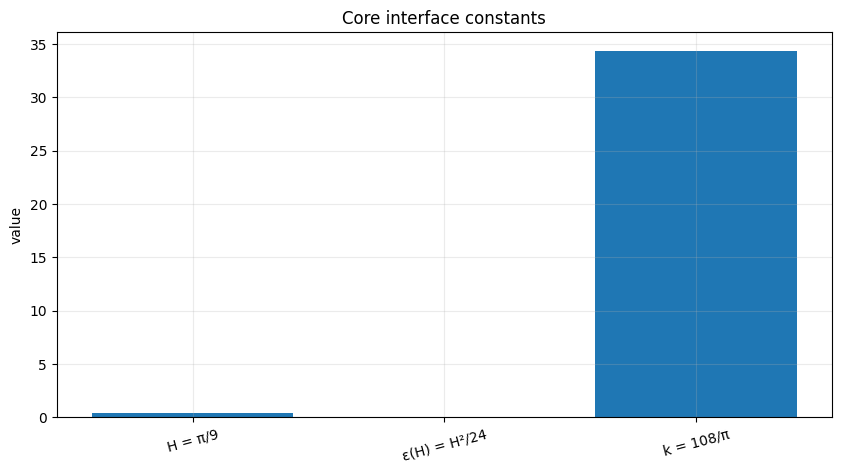

In [4]:

fig, ax = plt.subplots()
vals = [float(H_mark1), float(eps_mark1), float(k_interface)]
labels = ["H = π/9", "ε(H) = H²/24", "k = 108/π"]
ax.bar(labels, vals)
ax.set_title("Core interface constants")
ax.set_ylabel("value")
plt.xticks(rotation=15)
plt.show()



Two immediate observations:

1. The residual $\varepsilon(H)$ is small but nonzero.
2. The attractor sits in a narrow band where a system can neither freeze nor explode.

That is exactly why the paper treats the residual not as a defect, but as the condition for history, memory, and causal differentiation.



## 2. Potential–Commitment–Value (PCV)

The paper’s triadic commit lattice centers on three co-occupying roles:

- **Potential**: what a state could become,
- **Commitment**: the closure operation,
- **Value**: the surviving readable witness.

A simple computational way to represent the structural requirement is:

$$
\text{realized state} \iff P(s)\neq\varnothing,\; C(s)\neq\varnothing,\; V(s)\neq\varnothing.
$$

This section does **not** claim a unique dynamical law for PCV. Instead, it builds a compact companion representation showing why the triad is fundamentally three-place rather than binary.


In [5]:

pcv_states = []
for P in [0, 1]:
    for C in [0, 1]:
        for V in [0, 1]:
            realized = int(P == 1 and C == 1 and V == 1)
            pcv_states.append({
                "Potential": P,
                "Commitment": C,
                "Value": V,
                "Realized physical state?": realized
            })
pcv_df = pd.DataFrame(pcv_states)
pcv_df


,Potential,Commitment,Value,Realized physical state?
0,0,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,1,1,0
4,1,0,0,0
5,1,0,1,0
6,1,1,0,0
7,1,1,1,1


In [6]:

pcv_df.groupby("Realized physical state?").size().rename("count")


Realized physical state?
0    7
1    1
Name: count, dtype: int64


Only the simultaneous triad $(1,1,1)$ survives under this minimal structural criterion.

A binary model can say *something is present* or *something changes*, but it cannot express the full packet logic of:

- pre-resolution possibility,
- closure,
- witness.

That is the notebook’s minimal computational reading of why the paper insists the primitive closed state is triadic rather than linear.



## 3. Equality as active closure and many-to-one architecture

A major inversion in the paper is that equality is not passive noun-sameness. It is a **collapse relation**:

multiple upstream routes can land on the same readable witness.

The simplest concrete place to see this is ordinary addition.  
For a fixed sum $S$, many ordered pairs $(a,b)$ satisfy

$$
a+b=S.
$$

So the visible witness $S$ is many-to-one with respect to route history.


In [7]:

sum_classes = defaultdict(list)
for a in range(10):
    for b in range(10):
        sum_classes[a+b].append((a, b, as_expr(a, b), packet_N(a, b)))

collapse_rows = []
for s, routes in sorted(sum_classes.items()):
    collapse_rows.append({
        "sum": s,
        "route_count": len(routes),
        "example_routes": ", ".join(expr for _, _, expr, _ in routes[:5]) + (" ..." if len(routes) > 5 else "")
    })
collapse_df = pd.DataFrame(collapse_rows)
collapse_df


,sum,route_count,example_routes
0,0,1,0+0=
1,1,2,"0+1=, 1+0="
2,2,3,"0+2=, 1+1=, 2+0="
3,3,4,"0+3=, 1+2=, 2+1=, 3+0="
4,4,5,"0+4=, 1+3=, 2+2=, 3+1=, 4+0="
5,5,6,"0+5=, 1+4=, 2+3=, 3+2=, 4+1= ..."
6,6,7,"0+6=, 1+5=, 2+4=, 3+3=, 4+2= ..."
7,7,8,"0+7=, 1+6=, 2+5=, 3+4=, 4+3= ..."
8,8,9,"0+8=, 1+7=, 2+6=, 3+5=, 4+4= ..."
9,9,10,"0+9=, 1+8=, 2+7=, 3+6=, 4+5= ..."


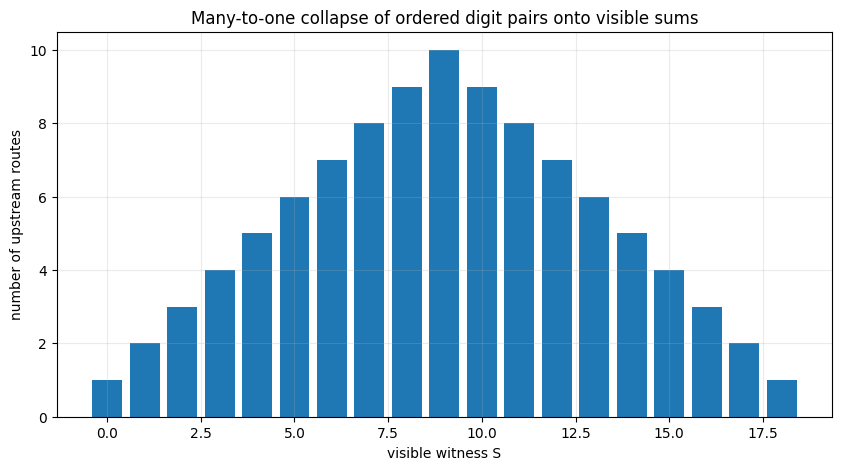

In [8]:

fig, ax = plt.subplots()
ax.bar(collapse_df["sum"], collapse_df["route_count"])
ax.set_title("Many-to-one collapse of ordered digit pairs onto visible sums")
ax.set_xlabel("visible witness S")
ax.set_ylabel("number of upstream routes")
plt.show()



The arithmetic answer collapses route history.

But the **packet** does not.

That is the core move into the next section.



## 4. The generative triplex and the 64-frame motif

The paper highlights the triplex
$$
(\pi,\;e,\;\varphi)
$$
and emphasizes the integer parts

$$
3,\;2,\;1
$$

whose sum is

$$
3+2+1=6.
$$

It also stresses the recurrence of **64** as a stable closure scale across computation, biology, and cryptography.

This section computes the triplex numerically and gives a compact reproducible table for the 64-motif.


In [9]:

triplex_df = pd.DataFrame({
    "constant": ["π", "e", "φ"],
    "value": [float(pi), float(E), float(GoldenRatio)],
    "integer_part": [math.floor(float(pi)), math.floor(float(E)), math.floor(float(GoldenRatio))]
})
triplex_df


,constant,value,integer_part
0,π,3.141593,3
1,e,2.718282,2
2,φ,1.618034,1


In [10]:

triplex_integer_sum = triplex_df["integer_part"].sum()
triplex_integer_sum


np.int64(6)

In [11]:

universality_64 = pd.DataFrame({
    "domain": [
        "binary closure",
        "2D square state count",
        "genetic codons",
        "SHA-256 rounds",
        "SHA-256 K constants"
    ],
    "expression": [
        "2^6",
        "8×8",
        "4^3",
        "64 rounds",
        "first 64 primes → cube-root constants"
    ],
    "value": [2**6, 8*8, 4**3, 64, 64]
})
universality_64


,domain,expression,value
0,binary closure,2^6,64
1,2D square state count,8×8,64
2,genetic codons,4^3,64
3,SHA-256 rounds,64 rounds,64
4,SHA-256 K constants,first 64 primes → cube-root constants,64



The notebook is not trying to prove that every occurrence of 64 is the *same thing*.  
It is showing the computational fact that the paper’s 64-frame motif is concrete, enumerable, and reproducible.



## 5. The 3–5–7 system and balanced ternary closure

The paper defines the phase map

$$
\phi(3)=-1,\qquad \phi(5)=0,\qquad \phi(7)=+1.
$$

For a finite word
$$
w = a_n a_{n-1}\dots a_0,
\qquad a_k \in \{3,5,7\},
$$
the structural value is

$$
V(w)=\sum_{k=0}^{n}\phi(a_k)3^k.
$$

This is balanced ternary encoded on the alphabet $\{3,5,7\}$.


In [12]:

phi_map = {3: -1, 5: 0, 7: 1}
inv_phi = {-1: 3, 0: 5, 1: 7}

def value_357(word: str) -> int:
    digits = [int(ch) for ch in word]
    total = 0
    for k, d in enumerate(reversed(digits)):
        total += phi_map[d] * (3 ** k)
    return total

def int_to_balanced_ternary(n: int):
    if n == 0:
        return [0]
    digits = []
    x = n
    while x != 0:
        x, r = divmod(x, 3)
        if r == 2:
            r = -1
            x += 1
        digits.append(r)
    return digits  # least-significant first

def int_to_357(n: int) -> str:
    bt = int_to_balanced_ternary(n)
    return "".join(str(inv_phi[d]) for d in reversed(bt))

def add_bt(x: int, y: int) -> int:
    return x + y

def mul_bt(x: int, y: int) -> int:
    return x * y

examples = pd.DataFrame({
    "word": ["5", "7", "73", "733"],
    "value": [value_357("5"), value_357("7"), value_357("73"), value_357("733")]
})
examples


,word,value
0,5,0
1,7,1
2,73,2
3,733,5


In [13]:

ints = list(range(-13, 14))
enc_df = pd.DataFrame({
    "integer": ints,
    "357_encoding": [int_to_357(n) for n in ints]
})
enc_df


,integer,357_encoding
0,-13,333
1,-12,335
2,-11,337
3,-10,353
4,-9,355
...,...,...
22,9,755
23,10,757
24,11,773
25,12,775


In [14]:

# Verify the paper's two explicit examples
assert value_357("73") == 2
assert value_357("733") == 5

# Round-trip test for a moderate interval
for n in range(-100, 101):
    assert value_357(int_to_357(n)) == n

print("357 encoding round-trip verified for integers in [-100, 100].")


357 encoding round-trip verified for integers in [-100, 100].



### Uniqueness of the 5-hinge

The paper emphasizes that

$$
3,\;5,\;7
$$

is the only overlapping twin-prime chain.

We can verify this directly and also restate the modular reason:

Any centered odd gap-2 triple has the form

$$
(x-2,\;x,\;x+2).
$$

Modulo $3$, these are always one representative each of

$$
-1,\;0,\;+1 \pmod 3.
$$

So one member is always divisible by $3$.  
For all three members to remain prime, that divisible member must literally be $3$.

Therefore the only overlapping twin-prime chain is

$$
\boxed{3,\;5,\;7.}
$$


In [15]:

def is_prime(n: int) -> bool:
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    r = int(n**0.5)
    for d in range(3, r+1, 2):
        if n % d == 0:
            return False
    return True

triples = []
for center in range(3, 1000, 2):
    triple = (center-2, center, center+2)
    if all(is_prime(x) for x in triple):
        triples.append(triple)
triples[:10], len(triples)


([(3, 5, 7)], 1)

In [16]:

assert triples == [(3, 5, 7)]
print("Unique overlapping twin-prime chain up to 1000:", triples)


Unique overlapping twin-prime chain up to 1000: [(3, 5, 7)]



## 6. ASCII packet laws and modular route matrices

For single decimal digits $a,b \in \{0,\dots,9\}$, the expression

$$
\texttt{"a+b="}
$$

is encoded as the 32-bit integer

$$
N(a,b)=((48+a)\ll 24) + (43\ll 16) + ((48+b)\ll 8) + 61.
$$

This retains:

- left operand,
- operator,
- right operand,
- terminator

in distinct byte lanes.


In [17]:

packet_table = []
for a in range(10):
    for b in range(10):
        N = packet_N(a, b)
        packet_table.append({
            "a": a,
            "b": b,
            "expr": as_expr(a, b),
            "N": N,
            "hex": hex(N),
            "bytes": packet_bytes(a, b),
            "sum": a+b
        })
packet_df = pd.DataFrame(packet_table)
packet_df.head(12)


,a,b,expr,N,hex,bytes,sum
0,0,0,0+0=,808136765,0x302b303d,"[48, 43, 48, 61]",0
1,0,1,0+1=,808137021,0x302b313d,"[48, 43, 49, 61]",1
2,0,2,0+2=,808137277,0x302b323d,"[48, 43, 50, 61]",2
3,0,3,0+3=,808137533,0x302b333d,"[48, 43, 51, 61]",3
4,0,4,0+4=,808137789,0x302b343d,"[48, 43, 52, 61]",4
5,0,5,0+5=,808138045,0x302b353d,"[48, 43, 53, 61]",5
6,0,6,0+6=,808138301,0x302b363d,"[48, 43, 54, 61]",6
7,0,7,0+7=,808138557,0x302b373d,"[48, 43, 55, 61]",7
8,0,8,0+8=,808138813,0x302b383d,"[48, 43, 56, 61]",8
9,0,9,0+9=,808139069,0x302b393d,"[48, 43, 57, 61]",9



### Modulo 100 residue-grid law

The paper states the closed form

$$
N(a,b)\equiv 16a + 56b + 65 \pmod{100}.
$$

We verify it exhaustively.


In [18]:

def residue100_closed(a: int, b: int) -> int:
    return (16*a + 56*b + 65) % 100

checks_100 = []
for a in range(10):
    for b in range(10):
        lhs = packet_N(a, b) % 100
        rhs = residue100_closed(a, b)
        checks_100.append(lhs == rhs)

all(checks_100), sum(checks_100), len(checks_100)


(True, 100, 100)

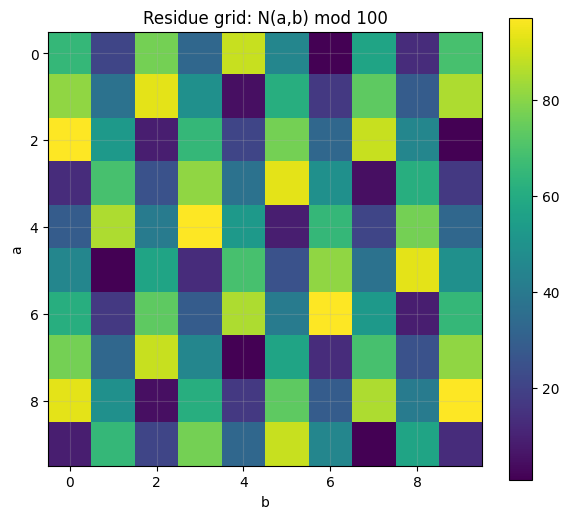

In [19]:

res100_grid = np.array([[packet_N(a, b) % 100 for b in range(10)] for a in range(10)])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(res100_grid, cmap="viridis")
ax.set_title("Residue grid: N(a,b) mod 100")
ax.set_xlabel("b")
ax.set_ylabel("a")
fig.colorbar(im, ax=ax)
plt.show()



### Modulo 10 surface-fold law

For
$$
S = a+b,
$$
the paper gives

$$
N(a,b)\equiv 6S+5 \pmod{10}.
$$

We again verify it exhaustively.


In [20]:

def lastdigit_closed(a: int, b: int) -> int:
    S = a + b
    return (6*S + 5) % 10

checks_10 = []
for a in range(10):
    for b in range(10):
        lhs = packet_N(a, b) % 10
        rhs = lastdigit_closed(a, b)
        checks_10.append(lhs == rhs)

all(checks_10), sum(checks_10), len(checks_10)


(True, 100, 100)

In [21]:

parity_rows = []
for S in range(19):
    parity_rows.append({
        "S": S,
        "S mod 2": S % 2,
        "surface residue (6S+5) mod 10": (6*S + 5) % 10
    })
pd.DataFrame(parity_rows)


,S,S mod 2,surface residue (6S+5) mod 10
0,0,0,5
1,1,1,1
2,2,0,7
3,3,1,3
4,4,0,9
5,5,1,5
6,6,0,1
7,7,1,7
8,8,0,3
9,9,1,9



This gives the visible parity split noted in the paper:

- odd sums surface directly,
- even sums are shifted by $5$ in the modulo-10 fold.

The point is not ordinary arithmetic correctness.  
It is that the **packet witness** preserves a structured scar of the route rather than collapsing all detail into the naked sum.



### Modulo 9 hidden-route law

The paper states that, since

$$
256 \equiv 4 \pmod 9,
$$

the byte weights cycle as

$$
1,\;4,\;7,\;1 \pmod 9,
$$

and the packed integer obeys

$$
N(a,b)\equiv (a+b)-1+3b \pmod 9.
$$

We verify this across the full $10\times 10$ digit lattice.


In [22]:

def route9_closed(a: int, b: int) -> int:
    return ((a+b) - 1 + 3*b) % 9

checks_9 = []
for a in range(10):
    for b in range(10):
        lhs = packet_N(a, b) % 9
        rhs = route9_closed(a, b)
        checks_9.append(lhs == rhs)

all(checks_9), sum(checks_9), len(checks_9)


(True, 100, 100)

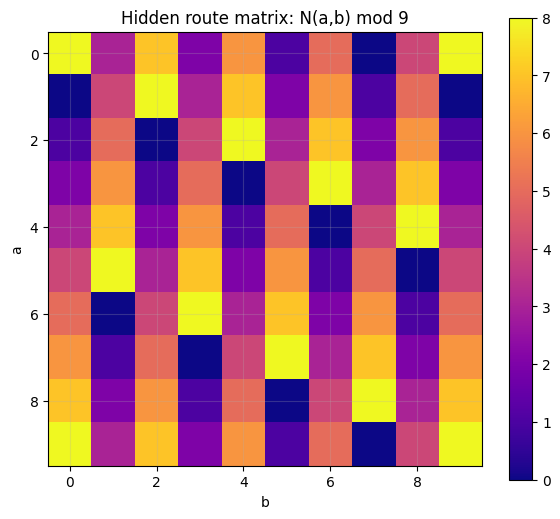

In [23]:

route9_grid = np.array([[packet_N(a, b) % 9 for b in range(10)] for a in range(10)])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(route9_grid, cmap="plasma")
ax.set_title("Hidden route matrix: N(a,b) mod 9")
ax.set_xlabel("b")
ax.set_ylabel("a")
fig.colorbar(im, ax=ax)
plt.show()



The paper interprets this as a deterministic route lattice in $\mathbb Z_9$.

A compact companion way to see the structure is to separate the two controls:

- the sum class $a+b$,
- the right-hand operand class $b \bmod 3$.

That yields a $3\times 3$ route grammar.


In [24]:

route_lattice = np.empty((3, 3), dtype=int)
for s_mod3 in range(3):
    for b_mod3 in range(3):
        route_lattice[s_mod3, b_mod3] = ((s_mod3) - 1 + 3*b_mod3) % 9

route_lattice_df = pd.DataFrame(
    route_lattice,
    index=[f"(a+b) mod 3 = {i}" for i in range(3)],
    columns=[f"b mod 3 = {j}" for j in range(3)]
)
route_lattice_df


,b mod 3 = 0,b mod 3 = 1,b mod 3 = 2
(a+b) mod 3 = 0,8,2,5
(a+b) mod 3 = 1,0,3,6
(a+b) mod 3 = 2,1,4,7



## 7. Route recovery and invertibility

The paper emphasizes that the bare visible answer is not enough to recover the path, but that the packet still preserves enough structure to make the route backward-solvable once appropriate invariants are included.

A natural exact invariant is the skew

$$
k = a-b.
$$

Together with the sum

$$
s = a+b,
$$

we recover

$$
a = \frac{s+k}{2},
\qquad
b = \frac{s-k}{2}.
$$

This is the cleanest algebraic inversion.


In [25]:

def recover_ab_from_sum_and_skew(s: int, k: int):
    a = (s + k) / 2
    b = (s - k) / 2
    return a, b

recovery_examples = []
for a in range(10):
    for b in range(10):
        s = a + b
        k = a - b
        ar, br = recover_ab_from_sum_and_skew(s, k)
        recovery_examples.append({
            "a": a, "b": b, "sum": s, "skew": k,
            "recovered_a": ar, "recovered_b": br,
            "exact?": (ar == a and br == b)
        })

recovery_df = pd.DataFrame(recovery_examples)
recovery_df["exact?"].all(), recovery_df.shape[0]


(np.True_, 100)


So the witness did not erase the path.

It compressed it.

That is one of the clearest fully explicit computational ideas in the paper, and it is one of the strongest sections to keep in any publication notebook.



## 8. Projection operators as preserved scars

The paper treats bases and modular projections as **operators** that expose different surviving invariants of one underlying packet.

We can inspect the same packet through several lenses:

- byte lanes,
- hexadecimal,
- binary length,
- modulo 100,
- modulo 10,
- modulo 9,
- SHA-256 digest of the symbolic expression itself.


In [26]:

def inspect_packet(a: int, b: int):
    expr = as_expr(a, b)
    N = packet_N(a, b)
    return {
        "expr": expr,
        "bytes": packet_bytes(a, b),
        "hex": hex(N),
        "binary_length": N.bit_length(),
        "mod100": N % 100,
        "mod10": N % 10,
        "mod9": N % 9,
        "sha256": sha256_hex(expr)[:24] + "..."
    }

pd.DataFrame([
    inspect_packet(1, 4),
    inspect_packet(4, 1),
    inspect_packet(3, 5),
    inspect_packet(5, 3),
])


,expr,bytes,hex,binary_length,mod100,mod10,mod9,sha256
0,1+4=,"[49, 43, 52, 61]",0x312b343d,30,5,5,7,7466e143781980a19c81b665...
1,4+1=,"[52, 43, 49, 61]",0x342b313d,30,85,5,7,662cd28722da8cdc8b48a333...
2,3+5=,"[51, 43, 53, 61]",0x332b353d,30,93,3,4,9639e4b5de0a43f9f53938f7...
3,5+3=,"[53, 43, 51, 61]",0x352b333d,30,13,3,7,a2ab7ae5fee5dc55ef33572c...



This is the notebook version of the paper’s projection claim:

the packet is primary; each basis reveals a different scar of the collapse.

The witnesses are not identical, even when arithmetic closure is commutative.



## 9. A minimal AHRC-style contraction experiment

The paper’s AHRC section is conceptually rich, but not every control equation is given in a single explicit implementation-ready form.

So here we include a **minimal companion reducer**, clearly marked as a companion realization rather than a claimed unique derivation.

We define a scalar state $x_t$ trying to phase-lock to the Mark 1 attractor $H$:

$$
\Delta_t = x_t - H
$$

and update by a simple contraction with optional leakage term:

$$
x_{t+1}=x_t-\lambda \Delta_t + \mu \sin(\pi t / T)\Delta_t.
$$

When $\mu=0$, this is pure contraction.  
When $\mu\neq 0$, it becomes a lightly perturbed self-correcting raster.


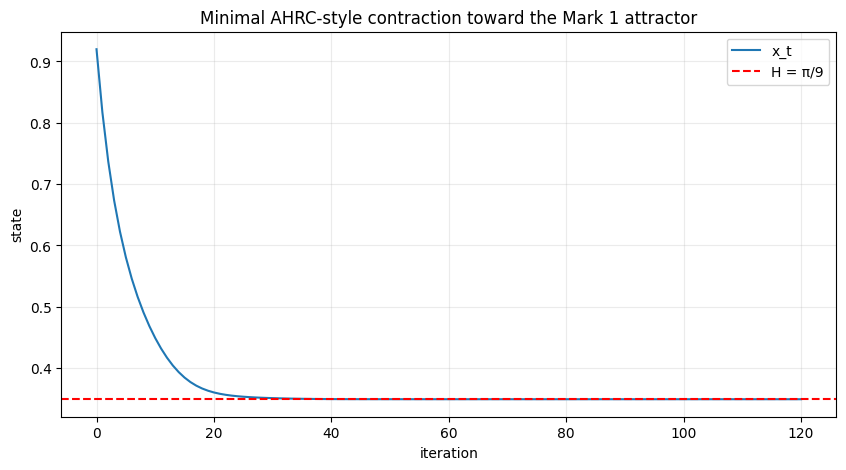

In [27]:

def ahc_companion(x0=0.92, H=float(H_mark1), lam=0.18, mu=0.03, T=11, steps=120):
    xs = [x0]
    for t in range(steps):
        x = xs[-1]
        delta = x - H
        correction = lam * delta - mu * math.sin(math.pi * t / T) * delta
        xs.append(x - correction)
    return np.array(xs)

traj = ahc_companion()
target = float(H_mark1)

fig, ax = plt.subplots()
ax.plot(traj, label="x_t")
ax.axhline(target, color="red", linestyle="--", label="H = π/9")
ax.set_title("Minimal AHRC-style contraction toward the Mark 1 attractor")
ax.set_xlabel("iteration")
ax.set_ylabel("state")
ax.legend()
plt.show()


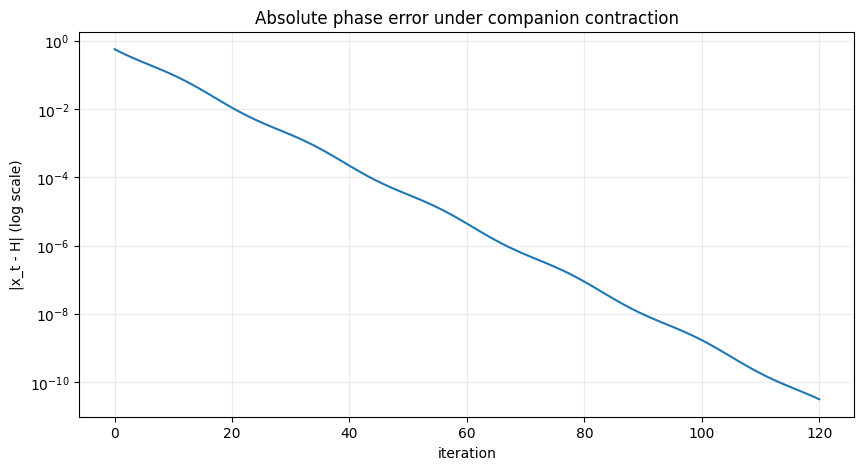

In [28]:

errors = np.abs(traj - target)

fig, ax = plt.subplots()
ax.semilogy(errors + 1e-16)
ax.set_title("Absolute phase error under companion contraction")
ax.set_xlabel("iteration")
ax.set_ylabel("|x_t - H| (log scale)")
plt.show()



This companion model is useful for publication because it does three things cleanly:

1. it makes the attractor concrete,
2. it shows how residual-guided correction can stabilize a state,
3. it gives a reproducible numerical object for future refinements.

It should be read as a **sandboxed companion realization**, not as a final claim that the AHRC law is uniquely this scalar recurrence.



## 10. Compact SHA / route-history demonstration

The paper places cryptographic hashing inside a many-to-one architecture and treats hash-like collapse as a structured witness rather than blind destruction.

A minimal reproducible companion test is to compare two expressions with the same visible arithmetic result but different route histories.


In [29]:

same_sum_pairs = [(1, 4), (2, 3), (4, 1), (0, 5), (5, 0)]
sha_rows = []
for a, b in same_sum_pairs:
    expr = as_expr(a, b)
    sha_rows.append({
        "expr": expr,
        "visible_sum": a+b,
        "packet_hex": hex(packet_N(a, b)),
        "sha256_prefix": sha256_hex(expr)[:20]
    })

sha_df = pd.DataFrame(sha_rows)
sha_df


,expr,visible_sum,packet_hex,sha256_prefix
0,1+4=,5,0x312b343d,7466e143781980a19c81
1,2+3=,5,0x322b333d,de6e11e327b7ff008954
2,4+1=,5,0x342b313d,662cd28722da8cdc8b48
3,0+5=,5,0x302b353d,8c3748ec5991edb37406
4,5+0=,5,0x352b303d,574edd924f3b826c8828


In [30]:

# Pairwise Hamming distances between the first 64 bits of the SHA-256 digests
digests_64 = {expr: int(sha256_hex(expr)[:16], 16) for expr in sha_df["expr"]}

dist_rows = []
exprs = list(digests_64.keys())
for i in range(len(exprs)):
    for j in range(i+1, len(exprs)):
        e1, e2 = exprs[i], exprs[j]
        dist_rows.append({
            "expr_1": e1,
            "expr_2": e2,
            "same_visible_sum": True,
            "hamming_distance_first64": hamming_distance(digests_64[e1], digests_64[e2])
        })

pd.DataFrame(dist_rows)


,expr_1,expr_2,same_visible_sum,hamming_distance_first64
0,1+4=,2+3=,True,32
1,1+4=,4+1=,True,28
2,1+4=,0+5=,True,29
3,1+4=,5+0=,True,26
4,2+3=,4+1=,True,30
5,2+3=,0+5=,True,31
6,2+3=,5+0=,True,28
7,4+1=,0+5=,True,37
8,4+1=,5+0=,True,28
9,0+5=,5+0=,True,41



Even when the arithmetic witness is the same, the symbolic route packet is not.

That is the notebook-scale computational version of the paper’s many-to-one collapse architecture:

- arithmetic collapses to the sum,
- packet structure preserves the route,
- projection operators reveal different scars of that route.



## 11. Compact synthesis tables

We now collect the strongest paper-anchored notebook results in one place.


In [31]:

summary_rows = [
    ("Mark 1 attractor", "H = π/9", float(H_mark1)),
    ("Residual", "ε(H) = H²/24", float(eps_mark1)),
    ("Triplex integer sum", "⌊π⌋ + ⌊e⌋ + ⌊φ⌋", triplex_integer_sum),
    ("357 uniqueness", "Only overlapping twin-prime chain below 1000", triples),
    ("Residue-grid law", "N(a,b) ≡ 16a + 56b + 65 (mod 100)", all(checks_100)),
    ("Surface-fold law", "N(a,b) ≡ 6(a+b)+5 (mod 10)", all(checks_10)),
    ("Hidden route law", "N(a,b) ≡ (a+b)-1+3b (mod 9)", all(checks_9)),
    ("Route recovery", "(s,k) ↦ (a,b) exact on digit range", recovery_df["exact?"].all()),
]
summary_df = pd.DataFrame(summary_rows, columns=["component", "formula / statement", "result"])
summary_df


,component,formula / statement,result
0,Mark 1 attractor,H = π/9,0.349066
1,Residual,ε(H) = H²/24,0.005077
2,Triplex integer sum,⌊π⌋ + ⌊e⌋ + ⌊φ⌋,6
3,357 uniqueness,Only overlapping twin-prime chain below 1000,"[(3, 5, 7)]"
4,Residue-grid law,"N(a,b) ≡ 16a + 56b + 65 (mod 100)",True
5,Surface-fold law,"N(a,b) ≡ 6(a+b)+5 (mod 10)",True
6,Hidden route law,"N(a,b) ≡ (a+b)-1+3b (mod 9)",True
7,Route recovery,"(s,k) ↦ (a,b) exact on digit range",True



## 12. Conclusions

This notebook does **not** try to restage the entire philosophical argument of the paper.

Instead, it makes the strongest computational pieces explicit and runnable:

- the Mark 1 attractor and interface residual,
- the triadic closure logic,
- the many-to-one route collapse of equality,
- the 3–5–7 balanced ternary lattice,
- the ASCII packet laws,
- the route-recovery logic,
- the projection-scar viewpoint,
- and a minimal contraction experiment around the AHRC idea.

### What is strongest here

The most concrete publication-ready sections are:

1. **The 3–5–7 encoding and uniqueness of the 5-hinge**
2. **The ASCII packet laws**
3. **The mod 100 / mod 10 / mod 9 residue checks**
4. **The route-recovery inversion**
5. **The many-to-one collapse demonstrations**

### Natural extensions

The next notebook versions could add:

- direct SHA-256 round instrumentation,
- a fuller Byte1-of-$\pi$ reconstruction if the exact algorithm is formalized,
- protein-fold hinge scans,
- gravitational mode-gate analogues,
- typed prime-gap wheel companions.

This notebook is therefore a **full runnable companion** for the current paper, while remaining conservative about which equations are treated as explicit and which are presented as companion realizations.
